# **Importing Libraries**

In [7]:
import re
import fitz  
import numpy as np
import easyocr
import unicodedata
import faiss
from sentence_transformers import SentenceTransformer, CrossEncoder
import os
from groq import Groq

# **English Text Processing**

In [8]:
ENGLISH_PDF = "data/dostor in english.pdf"

print("=" * 50)
print("ENGLISH PDF — OCR EXTRACTION (EasyOCR)")
print("=" * 50)

reader = easyocr.Reader(['en'], gpu=True)
print("✅ EasyOCR model loaded")

doc = fitz.open(ENGLISH_PDF)
print(f"Total pages: {len(doc)}")

raw_text_en = ""
for i, page in enumerate(doc):
    # convert page to image at 300 DPI
    mat = fitz.Matrix(300 / 72, 300 / 72)
    pix = page.get_pixmap(matrix=mat)
    
    # Convert image to numpy array for EasyOCR
    img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(
        pix.height, pix.width, pix.n
    )
    
    # If image has alpha channel (4 channels), drop it bec EasyOCR expects RGB (3 channels)
    if pix.n == 4:
        img = img[:, :, :3]
    
    # detail=0 returns plain text list, detail=1 returns bounding boxes too
    results = reader.readtext(img, detail=0, paragraph=True)
    page_text = "\n".join(results)
    raw_text_en += page_text + "\n"
    print(f"  [EN] Processed page {i + 1}/{len(doc)}")

doc.close()
print(f"\nRaw English text length : {len(raw_text_en):,} characters")
print("---preview ---")
print(raw_text_en[7787:9500])

ENGLISH PDF — OCR EXTRACTION (EasyOCR)
✅ EasyOCR model loaded
Total pages: 124
  [EN] Processed page 1/124
  [EN] Processed page 2/124
  [EN] Processed page 3/124
  [EN] Processed page 4/124
  [EN] Processed page 5/124
  [EN] Processed page 6/124
  [EN] Processed page 7/124
  [EN] Processed page 8/124
  [EN] Processed page 9/124
  [EN] Processed page 10/124
  [EN] Processed page 11/124
  [EN] Processed page 12/124
  [EN] Processed page 13/124
  [EN] Processed page 14/124
  [EN] Processed page 15/124
  [EN] Processed page 16/124
  [EN] Processed page 17/124
  [EN] Processed page 18/124
  [EN] Processed page 19/124
  [EN] Processed page 20/124
  [EN] Processed page 21/124
  [EN] Processed page 22/124
  [EN] Processed page 23/124
  [EN] Processed page 24/124
  [EN] Processed page 25/124
  [EN] Processed page 26/124
  [EN] Processed page 27/124
  [EN] Processed page 28/124
  [EN] Processed page 29/124
  [EN] Processed page 30/124
  [EN] Processed page 31/124
  [EN] Processed page 32/124
  

In [9]:
# After your OCR loop finishes
with open("extracted_text_en.txt", "w", encoding="utf-8") as f:
    f.write(raw_text_en)
print("✅ Text saved to extracted_text_en.txt")

✅ Text saved to extracted_text_en.txt


In [10]:
def clean_ocr_english(text: str) -> str:
    # Common OCR mis-reads of "Article"
    text = re.sub(
        r'\bArtic1e\b|\bArticie\b|\bARTIC1E\b|\bArt1cle\b',
        'Article', text, flags=re.IGNORECASE
    )
    # Collapse all whitespace to single space
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

clean_text_en = clean_ocr_english(raw_text_en)

print("=" * 50)
print("ENGLISH — AFTER CLEANING")
print("=" * 50)
print(f"Cleaned text length : {len(clean_text_en):,} characters")
print("---preview ---")
print(clean_text_en[7787:9500])

ENGLISH — AFTER CLEANING
Cleaned text length : 138,894 characters
---preview ---
 Article (1) The Arab Republic of Egypt is a sovereign, united and indivisible State, where no part may be given up, having a democratic republican system that is based on citizenship and rule of law: The Egyptian people are part of the Arab nation seeking to enhance its integration and unity. Egypt is part of the Islamic world, belongs to the African continent; cherishes its Asian dimension, and contributes to building human civilization. Article (2) Islam is the official religion of the State, its official language is Arabic. The principles of Islamic Sharia are the main source of legislation: Article (3) The principles of Christian and Jewish canons of Egyptian Christians and Jews are the main source of legislations that regulate their respective personal status, religious affairs, and selection of their religious leaders: Article (4) Sovereignty belongs only to the people, who shall exercise and protec

In [11]:
def split_articles_english(text: str) -> list[dict]:
    """
    It finds patterns like:Article (1) ,Article( 2 ) ,Article (3)
    """
    pattern = r'(Article\s*\(\s*\d+\s*\))'

    parts = re.split(pattern, text, flags=re.IGNORECASE) #Split text into chunks

    articles = []
    for i in range(1, len(parts), 2):
        header = parts[i].strip()
        body   = parts[i + 1].strip() if i + 1 < len(parts) else ""

        if len(body) < 20:
            continue

        num_match = re.search(r'\d+', header) # Extract article number from header
        num = int(num_match.group()) if num_match else -1 # Default to -1 if no number found

        articles.append({
            "article_id" : f"en_{num}",
            "article_num": num,
            "header"     : header,
            "text"       : f"{header} {body}",
            "lang"       : "en",
        })

    # Deduplicate — keep longest
    seen: dict[int, dict] = {}
    for art in articles:
        n = art["article_num"]
        if n not in seen or len(art["text"]) > len(seen[n]["text"]):
            seen[n] = art

    return sorted(seen.values(), key=lambda x: x["article_num"])


articles_en = split_articles_english(clean_text_en)

print("=" * 50)
print("ENGLISH — ARTICLE CHUNKING RESULTS")
print("=" * 50)
print(f"Total unique articles extracted : {len(articles_en)}")
print("--- First 5 articles ---")
for a in articles_en[:3]:
    print(a['text'])

ENGLISH — ARTICLE CHUNKING RESULTS
Total unique articles extracted : 254
--- First 5 articles ---
Article (1) The Arab Republic of Egypt is a sovereign, united and indivisible State, where no part may be given up, having a democratic republican system that is based on citizenship and rule of law: The Egyptian people are part of the Arab nation seeking to enhance its integration and unity. Egypt is part of the Islamic world, belongs to the African continent; cherishes its Asian dimension, and contributes to building human civilization.
Article (2) Islam is the official religion of the State, its official language is Arabic. The principles of Islamic Sharia are the main source of legislation:
Article (3) The principles of Christian and Jewish canons of Egyptian Christians and Jews are the main source of legislations that regulate their respective personal status, religious affairs, and selection of their religious leaders:


# **Arabic Text Processing**

In [12]:
_AR_INDIC = str.maketrans("٠١٢٣٤٥٦٧٨٩", "0123456789") #Converts Arabic-Indic digits → English digits

# Regex to handle kerning issues and RTL numbers (e.g., "م ا د ة ( 1 )")
_PAT_WITH_PAREN = re.compile(
    r"م\s?ا\s?د\s?ة\s*[\(\)]\s*"
    r"((?:[٠-٩]|\d)(?:[\n\s]*(?:[٠-٩]|\d))*)"
    r"\s*[\(\)]"
)
_PAT_NO_OPEN_PAREN = re.compile(r"مادة(\d+)\n\)")


def extract_text(pdf_path: str) -> str:
    """Extracts raw text from a native PDF."""
    doc = fitz.open(pdf_path)
    raw_text = "\n".join([page.get_text() for page in doc])
    doc.close()
    return raw_text


def clean_text(text: str) -> str:
    text = unicodedata.normalize("NFC", text)  #Fixes: broken Arabic character encoding and inconsistent Unicode forms
    
    # 1. Strip invisible bidi markers & Tashkeel
    for ch in '\u202a\u202b\u202c\u202d\u202e\u200e\u200f\u2066\u2067\u2068\u2069':
        text = text.replace(ch, '')
    text = re.sub(r'[\u0610-\u061A\u064B-\u065F]', '', text) 
    
    # ---------------------------------------------------------
    # ROOT FIX 1: Prefix Ligature Reversals
    # Fixes the engine reading "الإ" backwards as "اإل"
    # ---------------------------------------------------------
    text = text.replace("اإل", "الإ") 
    text = text.replace("األ", "الأ") 
    text = text.replace("اآل", "الآ") 
    
    # ---------------------------------------------------------
    # ROOT FIX 2: Word-Boundary Ligature Reversals ("لا" -> "ال")
    # ---------------------------------------------------------
    text = re.sub(r'\bال\b', 'لا', text)
    text = re.sub(r'\bوال\b', 'ولا', text)
    text = re.sub(r'\bإال\b', 'إلا', text)
    text = re.sub(r'\bأال\b', 'ألا', text)
    text = re.sub(r'\bفال\b', 'فلا', text)
    
    # ---------------------------------------------------------
    # ROOT FIX 3: Orphaned Letter De-fragmentation
    # Merges isolated letters back into their words (e.g., ال م حكمة -> المحكمة)
    # ---------------------------------------------------------
    text = re.sub(r'\b([بتثجحخدذرزسشصضطظعغفقكلمنهي])\s+', r'\1', text)
    
    # ---------------------------------------------------------
    # ROOT FIX 4: Generic Punctuation Spacing
    # ---------------------------------------------------------
    text = re.sub(r'\s+([،\.؛:؟!])', r'\1', text) # Remove space before punctuation
    text = re.sub(r'([،\.؛:؟!])(?=[^\s\d])', r'\1 ', text) # Add space after punctuation
    
    # 5. Clean excess whitespace
    return re.sub(r' {2,}', ' ', text).strip()


def _normalize_num(raw: str) -> int:
    """Handles RTL reversed digits extracted by the PDF engine."""
    d = "".join(raw.split())
    if re.fullmatch(r"[٠-٩]+", d):
        d = d[::-1] 
    return int(d.translate(_AR_INDIC))


def _normalize_body(body: str) -> str:
    """Fixes physical line breaks and orphaned trailing letters."""
    body = re.sub(r"([\u0600-\u06FF])\n([ىا])(?=[\n ،.،؟!]|$)", r"\1\2", body)
    body = re.sub(r"(?<!\n)\n(?!\n)", " ", body)
    return re.sub(r" +", " ", body).strip()


def chunk_articles(text: str, noise_phrases: list[str] = None) -> list[dict]:
    """Slices the text into structured dictionaries by article."""
    noise_phrases = noise_phrases or []
    seen: dict[int, int] = {}

    for m in _PAT_WITH_PAREN.finditer(text):
        try:
            n = _normalize_num(m.group(1))
            if n not in seen: seen[n] = m.start()
        except ValueError: continue

    for m in _PAT_NO_OPEN_PAREN.finditer(text):
        try:
            n = int(m.group(1))
            if n not in seen: seen[n] = m.start()
        except ValueError: continue

    headers = sorted((offset, num) for num, offset in seen.items())
    articles = []

    for i, (start, num) in enumerate(headers):
        end = headers[i + 1][0] if i + 1 < len(headers) else len(text)
        raw_body = text[start:end]
        
        raw_body = re.sub(r"^م\s?ا\s?د\s?ة[\s\S]{0,20}?\)\s*", "", raw_body).strip()
        if len(raw_body) < 10: continue
            
        body = _normalize_body(raw_body)
        
        # Strip whatever header noise the user passed in
        for noise in noise_phrases:
            body = body.replace(noise, '')
            
        articles.append({
            "article_id" : f"ar_{num}",
            "article_num": num,
            "header"     : f"مادة ({num})",
            "text"       : "\u200f" + f"مادة ({num})\n" + body.strip(),
            "lang"       : "ar",
        })

    articles.sort(key=lambda a: a["article_num"])
    return articles


def parse(pdf_path: str, noise_phrases: list[str] = None) -> list[dict]:
    """Executes the extraction, cleaning, and chunking pipeline."""
    print(f"📄 Extracting: {pdf_path} ...")
    raw_text = extract_text(pdf_path)
    
    print("🧹 Cleaning PDF artifacts and Arabic Ligatures...")
    clean_txt = clean_text(raw_text)
    
    print("✂️ Chunking into structural articles...")
    articles = chunk_articles(clean_txt, noise_phrases)
    
    print("\n" + "=" * 50)
    print("📊 PARSING REPORT")
    print("=" * 50)
    
    if articles:
        print(f"Total unique 'مادة' extracted: {len(articles)}")
        
        min_n = articles[0]["article_num"]
        max_n = articles[-1]["article_num"]
        found = {a["article_num"] for a in articles}
        missing = [n for n in range(min_n, max_n + 1) if n not in found]
        
        if missing:
            print(f"⚠️ Missing articles between {min_n} and {max_n}:\n   {missing}")
        else:
            print(f"✅ Sequence complete! All articles from {min_n} to {max_n} found.")
    else:
        print("❌ No articles found in document.")
        
    return articles


# ============================================================
# EXECUTION
# ============================================================

PDF_FILE = "data/dostor in arabic.pdf"

# Specific headers to ignore for this document
custom_noise_phrases = ['دستور جمهورية مصر العربية', 'ديباجة وثيقة الدستور']

# Run the pipeline
articles_ar = parse(PDF_FILE, noise_phrases=custom_noise_phrases)

# Print a preview
print("\n--- PREVIEW ---")
for a in articles_ar[:3]:
    print(f"\n[{a['article_id']}]\n{a['text']}")

📄 Extracting: data/dostor in arabic.pdf ...
🧹 Cleaning PDF artifacts and Arabic Ligatures...
✂️ Chunking into structural articles...

📊 PARSING REPORT
Total unique 'مادة' extracted: 254
✅ Sequence complete! All articles from 1 to 254 found.

--- PREVIEW ---

[ar_1]
‏مادة (1)
، جمهورية مصر العربية دولة ذات سيادة، موحدة لا تقبل التجزئة ولا ينزل عن شئ منها، نظامها جمهورى ديمقراطى، يقوم على أساس. المواطنة وسيادة القانون الشعب المصرى جزء من الأمة العربية يعمل على تكاملها ووح دتها، وم صر جزء من العالم الإسالمى، تنتمى، إلى القارة الإفريقية وتعتز بامتدادها الآسيوى، وتسهم فى. بناء الحضارة الإنسانية

[ar_2]
‏مادة (2)
الإسالم دين الدولة، واللغة العربية لغتها الرسمية، ومبادئ الشريعة. الإسالمية المصدر الرئيسى للتشريع

[ar_3]
‏مادة (3)
مبادئ شر ائع المصريين من المسيحيين واليهود المصدر الرئيسى، للتشريعات المنظ مة ألحوالهم الشخصية وشئونهم الدينية، واختيار. قياداتهم الروحية


# **Embeddings**

In [13]:
EMBED_MODEL_NAME = "paraphrase-multilingual-mpnet-base-v2"

embed_model = SentenceTransformer(EMBED_MODEL_NAME)

all_articles = articles_en + articles_ar
documents    = [a["text"] for a in all_articles]
metadatas    = [{
    "article_id" : a["article_id"],
    "article_num": a["article_num"],
    "lang"       : a["lang"],
} for a in all_articles]

print(f"\nEncoding {len(documents)}")

embeddings = embed_model.encode(
    documents,
    show_progress_bar=True,
    batch_size=32,
    convert_to_numpy=True,
)

print(f"✅ Embeddings shape : {embeddings.shape}")


Encoding 508


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

✅ Embeddings shape : (508, 768)


In [14]:
safe_embeddings = np.array(embeddings, dtype=np.float32)

dimension = safe_embeddings.shape[1] 

faiss.normalize_L2(safe_embeddings) #It converts each vector to unit length (L2 norm = 1). This is essential for cosine similarity 
index = faiss.IndexFlatIP(dimension) #Inner Product (IP) is used for cosine similarity when vectors are normalized to unit length

index.add(safe_embeddings)

print(f"✅ FAISS Index created successfully!")
print(f"✅ Stored {index.ntotal} chunks in FAISS.")
print(f"   English articles : {len([m for m in metadatas if m.get('lang') == 'en'])}")
print(f"   Arabic  articles : {len([m for m in metadatas if m.get('lang') == 'ar'])}")
print("=" * 50)

✅ FAISS Index created successfully!
✅ Stored 508 chunks in FAISS.
   English articles : 254
   Arabic  articles : 254


# **Re-ranking**

In [15]:
RERANKER_MODEL = "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1"

reranker = CrossEncoder(RERANKER_MODEL)

print(f"✅ Reranker loaded : {RERANKER_MODEL}")

✅ Reranker loaded : cross-encoder/mmarco-mMiniLMv2-L12-H384-v1


In [16]:
def retrieve_rerank(
    query: str,
    top_k: int = 10,
    final_k: int = 5,
    lang_filter: str | None = None,
) -> list[tuple]:

    query_embedding = embed_model.encode([query]) 
    query_embedding = np.array(query_embedding, dtype=np.float32)
    faiss.normalize_L2(query_embedding)
    
    # Determine how many vectors to pull
    # If we are filtering by language, pull extra to account for discarded wrong-language docs
    search_k = top_k * 5 if lang_filter else top_k  #
    
    # Search FAISS
    distances, indices = index.search(query_embedding, search_k)
    
    candidate_docs = []
    candidate_metas = []
    
    # 4. Map FAISS indices back to your data and apply the manual language filter
    for idx in indices[0]:
        if idx == -1: # FAISS returns -1 if it runs out of documents
            continue
            
        meta = metadatas[idx]
        
        # Apply the language filter manually
        if lang_filter and meta.get("lang") != lang_filter:
            continue
            
        # If it passes the filter, add it to our candidates
        candidate_docs.append(documents[idx])
        candidate_metas.append(meta)
        
        # Stop looping once we have exactly 'top_k' valid candidates
        if len(candidate_docs) == top_k:
            break

    # If no documents match, return empty
    if not candidate_docs:
        return []

    # 5. Rerank with CrossEncoder
    scores = reranker.predict([(query, doc) for doc in candidate_docs])
    
    # 6. Sort and return
    ranked = sorted(zip(candidate_docs, candidate_metas, scores), key=lambda x: x[2], reverse=True)
    
    return ranked[:final_k]

# **Answer Generation**

In [ ]:
# ============================================================
# Dual LLM Loading (Groq API: Qwen + Llama)
# ============================================================
print("=" * 50)
print("DUAL LLM — GROQ API (FREE TIER)")
print("=" * 50)

# Set your API key first


client = Groq(api_key=os.environ["GROQ_API_KEY"])

MODEL_CONFIGS = {
    "qwen": {
        "name": "qwen/qwen3-32b",   
        "description": "Strong multilingual (Arabic + English), best for RAG reasoning",
    },
    "llama": {
        "name": "llama-3.3-70b-versatile",
        "description": "Best reasoning + summarization, very strong general model",
    },
}

_active_key = [None]


def get_model(key: str):
    if key not in MODEL_CONFIGS:
        raise ValueError(f"Unknown model key: {key}")

    _active_key[0] = key
    return MODEL_CONFIGS[key]["name"]


def generate(key: str, messages, temperature=0.2, max_tokens=1024): # temperature : creativity control (0.0 = deterministic, 1.0 = very creative)
   
    model_name = get_model(key)

    response = client.chat.completions.create(
        model=model_name,
        messages=messages,
        temperature=temperature,
        max_tokens=max_tokens,
    )

    return response.choices[0].message.content # Extract the generated text from the response


print("   Available models:", list(MODEL_CONFIGS.keys()))

DUAL LLM — GROQ API (FREE TIER)
   Available models: ['qwen', 'llama']


In [18]:
def build_prompt(query: str, context: str, lang: str, model_key: str):

    if model_key == "llama":
        if lang == "ar":
            system_msg = (
                "أنت مساعد قانوني دقيق. "
                "استخدم فقط السياق المقدم لك. "
                "لا تضف أي معلومات خارج السياق. "
                "أجب في فقرة واحدة قصيرة فقط مع ذكر أرقام المواد."
            )
            user_msg = (
                f"السياق:\n{context}\n\n"
                f"السؤال: {query}\n\n"
                "أجب باختصار وبالاعتماد فقط على السياق:"
            )
        else:
            system_msg = (
                "You are a strict legal assistant. "
                "Use ONLY the provided context. "
                "Do NOT hallucinate or add external knowledge. "
                "Answer in ONE short paragraph and cite article numbers."
            )
            user_msg = (
                f"Context:\n{context}\n\n"
                f"Question: {query}\n\n"
                "Answer strictly using the context:"
            )
        return [
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg},
        ]

    # ── QWEN ──────────────────────────────────────────────────
    if lang == "ar":
        system_msg = (
            "أنت مساعد قانوني. القواعد الصارمة:\n"
            "1. استخدم السياق المقدم فقط.\n"
            "2. لا يُسمح باستخدام المعرفة الخارجية.\n"
            "3. فقرة واحدة فقط.\n"
            "4. اذكر أرقام المواد داخل النص.\n"
            "5. لا تتجاوز 100 كلمة."
        )
        user_msg = (
            f"السياق:\n{context}\n\n"
            f"السؤال: {query}\n\n"
            "/no_think\n"           # ← MUST be in user message for Qwen
            "أجب باختصار وبالاعتماد فقط على السياق:"
        )
    else:
        system_msg = (
            "You are a legal assistant. Strict rules:\n"
            "1. Use ONLY the given context.\n"
            "2. No external knowledge allowed.\n"
            "3. One paragraph only.\n"
            "4. Cite article numbers inline.\n"
            "5. Max 100 words."
        )
        user_msg = (
            f"Context:\n{context}\n\n"
            f"Question: {query}\n\n"
            "/no_think\n"           # ← MUST be in user message for Qwen
            "Answer strictly based on context:"
        )

    return [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg},
    ]


def generate_answer(
    query: str,
    lang: str = "auto",
    model_key: str = "qwen",
) -> tuple[str, list[str]]:

    import re

    if lang == "auto":
        arabic_chars = len(re.findall(r'[\u0600-\u06FF]', query))
        lang = "ar" if arabic_chars > len(query) * 0.3 else "en"

    print(f"\n[Language: {lang} | Model: {model_key}]")

    results = retrieve_rerank(query, lang_filter=lang)
    if not results:
        return "No relevant articles found.", []

    context, citations = "", []
    for doc, meta, score in results:
        context += doc + "\n\n"
        citations.append(meta["article_id"])
        print(f"  Retrieved: {meta['article_id']} (score={score:.3f})")

    messages = build_prompt(query, context, lang, model_key)
    model_name = MODEL_CONFIGS[model_key]["name"]

    response = client.chat.completions.create(
        model=model_name,
        messages=messages,
        temperature=0.1,
        max_tokens=300,     
        top_p=0.9,
    )

    answer = response.choices[0].message.content

    # ── Safety net: strip any leftover <think> blocks ──
    answer = re.sub(r'<think>.*?</think>', '', answer, flags=re.DOTALL).strip()
    answer = answer.split("\n\n")[0].strip()

    return answer, citations

In [ ]:
# ── English with Qwen ─────────────────────────────────────
print("=" * 50)
print("ENGLISH — Qwen")
print("=" * 50)
q_en = "What does the constitution say about freedom of expression?"
answer, cites = generate_answer(q_en, lang="en", model_key="qwen")
print(f"\nQ: {q_en}")
print(f"A: {answer}")
print(f"Citations: {cites}")

# ── English with Llama ────────────────────────────────────
print("\n" + "=" * 50)
print("ENGLISH — Llama")
print("=" * 50)
answer, cites = generate_answer(q_en, lang="en", model_key="llama")
print(f"\nQ: {q_en}")
print(f"A: {answer}")
print(f"Citations: {cites}")

# ── Arabic with Qwen ──────────────────────────────────────
print("\n" + "=" * 50)
print("ARABIC — Qwen")
print("=" * 50)
q_ar = "ما الذي يقوله الدستور عن حرية التعبير؟"
answer, cites = generate_answer(q_ar, lang="ar", model_key="qwen")
print(f"\nQ: {q_ar}")
print(f"A: {answer}")
print(f"Citations: {cites}")

# ── Arabic with Llama ─────────────────────────────────────
print("\n" + "=" * 50)
print("ARABIC — Llama")
print("=" * 50)
answer, cites = generate_answer(q_ar, lang="ar", model_key="llama")
print(f"\nQ: {q_ar}")
print(f"A: {answer}")
print(f"Citations: {cites}")

ENGLISH — Qwen

[Language: en | Model: qwen]
  Retrieved: en_65 (score=0.943)
  Retrieved: en_57 (score=-3.758)
  Retrieved: en_4 (score=-4.094)
  Retrieved: en_98 (score=-4.095)
  Retrieved: en_68 (score=-4.156)

Q: What does the constitution say about freedom of expression?
A: The Constitution guarantees freedom of thought and opinion, allowing every person the right to express their opinion verbally, in writing, through imagery, or by any other means of expression and publication, as stated in Article (65).
Citations: ['en_65', 'en_57', 'en_4', 'en_98', 'en_68']

ENGLISH — Llama

[Language: en | Model: llama]
  Retrieved: en_65 (score=0.943)
  Retrieved: en_57 (score=-3.758)
  Retrieved: en_4 (score=-4.094)
  Retrieved: en_98 (score=-4.095)
  Retrieved: en_68 (score=-4.156)

Q: What does the constitution say about freedom of expression?
A: According to Article (65), freedom of thought and opinion is guaranteed, and every person has the right to express their opinion verbally, in wri

# **Model Evaluation**

In [19]:
import json
import time
import numpy as np
import faiss
from dataclasses import dataclass, field, asdict
from typing import Optional


TEST_SET = [

    # ══════════════════════════════════════════════════════════════════════════
    # ENGLISH  (15 queries)
    # ══════════════════════════════════════════════════════════════════════════

    # ── State identity ────────────────────────────────────────────────────────
    {
        "query"          : "What does Article 54 of the Egyptian Constitution say about personal freedom??",
        "lang"           : "en",
        "expected_ids"   : ["en_54"],
        "expected_topic" : "System of government",
        "model_key"      : "qwen",
        "notes"          : "Art. 54 — Egypt is a sovereign unified democratic republic based on citizenship and rule of law.",
    },
    {
        "query"          : "What is the official religion and language of Egypt?",
        "lang"           : "en",
        "expected_ids"   : ["en_2"],
        "expected_topic" : "Official religion and language",
        "model_key"      : "qwen",
        "notes"          : "Art. 2 — Islam is the state religion, Arabic the official language, Islamic Sharia the main source of legislation.",
    },

    # ── Individual rights & freedoms ──────────────────────────────────────────
    {
        "query"          : "What does the constitution say about human dignity?",
        "lang"           : "en",
        "expected_ids"   : ["en_51"],
        "expected_topic" : "Human dignity",
        "model_key"      : "qwen",
        "notes"          : "Art. 51 — dignity is a right for every person; the state must respect and protect it.",
    },
    {
        "query"          : "What protection does the constitution give against torture?",
        "lang"           : "en",
        "expected_ids"   : ["en_52"],
        "expected_topic" : "Prohibition of torture",
        "model_key"      : "qwen",
        "notes"          : "Art. 52 — torture in all forms is a crime that does not expire by statute of limitations.",
    },
    {
        "query"          : "What does the constitution say about equality of citizens before the law?",
        "lang"           : "en",
        "expected_ids"   : ["en_53"],
        "expected_topic" : "Equality before the law",
        "model_key"      : "qwen",
        "notes"          : "Art. 53 — all citizens equal, no discrimination by religion, gender, origin, or belief.",
    },
    {
        "query"          : "What are citizens' rights regarding personal freedom and arrest?",
        "lang"           : "en",
        "expected_ids"   : ["en_54"],
        "expected_topic" : "Personal freedom and arrest",
        "model_key"      : "qwen",
        "notes"          : "Art. 54 — personal liberty is a natural right; arrest only lawful under defined conditions.",
    },
    {
        "query"          : "Does the constitution protect the privacy of homes and communications?",
        "lang"           : "en",
        "expected_ids"   : ["en_57", "en_58"],
        "expected_topic" : "Privacy of home and communications",
        "model_key"      : "qwen",
        "notes"          : "Art. 57 — privacy of correspondence. Art. 58 — sanctity of the home.",
    },
    {
        "query"          : "Does the constitution guarantee the right to move freely and emigrate?",
        "lang"           : "en",
        "expected_ids"   : ["en_62"],
        "expected_topic" : "Freedom of movement and emigration",
        "model_key"      : "qwen",
        "notes"          : "Art. 62 — freedom of movement, residence, and emigration is guaranteed; no citizen may be expelled.",
    },
    {
        "query"          : "What does the constitution say about freedom of belief and religious practice?",
        "lang"           : "en",
        "expected_ids"   : ["en_64"],
        "expected_topic" : "Freedom of belief",
        "model_key"      : "qwen",
        "notes"          : "Art. 64 — freedom of belief is absolute; freedom of religious practice is a right regulated by law.",
    },
    {
        "query"          : "What does the constitution say about freedom of expression?",
        "lang"           : "en",
        "expected_ids"   : ["en_65"],
        "expected_topic" : "Freedom of expression",
        "model_key"      : "qwen",
        "notes"          : "Art. 65 — freedom of thought and opinion guaranteed; every person may express opinion by any means.",
    },

    # ── Social & economic rights ───────────────────────────────────────────────
    {
        "query"          : "Is the right to work and labour protection guaranteed?",
        "lang"           : "en",
        "expected_ids"   : ["en_12"],
        "expected_topic" : "Right to work",
        "model_key"      : "qwen",
        "notes"          : "Art. 12 — work is a right, duty, and honour guaranteed by the state.",
    },
    {
        "query"          : "Is the right to healthcare guaranteed in the constitution?",
        "lang"           : "en",
        "expected_ids"   : ["en_18"],
        "expected_topic" : "Right to healthcare",
        "model_key"      : "qwen",
        "notes"          : "Art. 18 — every citizen has the right to health and integrated healthcare.",
    },
    {
        "query"          : "What does the constitution say about the right to education?",
        "lang"           : "en",
        "expected_ids"   : ["en_19"],
        "expected_topic" : "Right to education",
        "model_key"      : "qwen",
        "notes"          : "Art. 19 — education is a right for every citizen aimed at building the Egyptian character.",
    },

    # ── Judicial & executive ──────────────────────────────────────────────────
    {
        "query"          : "Is judicial independence guaranteed?",
        "lang"           : "en",
        "expected_ids"   : ["en_184"],
        "expected_topic" : "Judicial independence",
        "model_key"      : "qwen",
        "notes"          : "Known edge case — MRR=0.25. Yes/no query phrasing causes reranker to rank Art.184 4th.",
    },
    {
        "query"          : "How many terms can the President serve and what is the term length?",
        "lang"           : "en",
        "expected_ids"   : ["en_140"],
        "expected_topic" : "Presidential term limits",
        "model_key"      : "llama",
        "notes"          : "Llama used intentionally — tests parametric memory override on numeric facts.",
    },

    # ══════════════════════════════════════════════════════════════════════════
    # ARABIC  (15 queries)
    # ══════════════════════════════════════════════════════════════════════════

    # ── State identity ────────────────────────────────────────────────────────
    {
        "query"          : "ما نظام الحكم في مصر وفقاً للدستور؟",
        "lang"           : "ar",
        "expected_ids"   : ["ar_1"],
        "expected_topic" : "نظام الحكم",
        "model_key"      : "qwen",
        "notes"          : "المادة 1 — جمهورية مصر العربية دولة ذات سيادة، نظامها جمهورى ديمقراطى.",
    },
    {
        "query"          : "ما هو الدين الرسمي للدولة المصرية واللغة الرسمية؟",
        "lang"           : "ar",
        "expected_ids"   : ["ar_2"],
        "expected_topic" : "الدين واللغة الرسمية",
        "model_key"      : "qwen",
        "notes"          : "المادة 2 — الإسلام دين الدولة، واللغة العربية لغتها الرسمية.",
    },
    {
        "query"          : "من يملك السيادة في مصر وفقاً للدستور؟",
        "lang"           : "ar",
        "expected_ids"   : ["ar_4"],
        "expected_topic" : "السيادة الشعبية",
        "model_key"      : "qwen",
        "notes"          : "المادة 4 — السيادة للشعب وحده، يمارسها ويحميها.",
    },

    # ── Individual rights & freedoms ──────────────────────────────────────────
    {
        "query"          : "ما الذي يقوله الدستور عن كرامة الإنسان؟",
        "lang"           : "ar",
        "expected_ids"   : ["ar_51"],
        "expected_topic" : "كرامة الإنسان",
        "model_key"      : "qwen",
        "notes"          : "المادة 51 — الكرامة حق لكل إنسان، وتلتزم الدولة باحترامها وحمايتها.",
    },
    {
        "query"          : "ما الذي يقوله الدستور عن حظر التعذيب؟",
        "lang"           : "ar",
        "expected_ids"   : ["ar_52"],
        "expected_topic" : "حظر التعذيب",
        "model_key"      : "qwen",
        "notes"          : "المادة 52 — التعذيب بجميع صوره وأشكاله جريمة لا تسقط بالتقادم.",
    },
    {
        "query"          : "ما الذي يقوله الدستور عن مبدأ المساواة وعدم التمييز؟",
        "lang"           : "ar",
        "expected_ids"   : ["ar_53"],
        "expected_topic" : "المساواة وعدم التمييز",
        "model_key"      : "qwen",
        "notes"          : "المادة 53 — المواطنون لدى القانون سواء، لا تمييز بسبب الدين أو الجنس أو الأصل.",
    },
    {
        "query"          : "ما الذي يقوله الدستور عن الحرية الشخصية والقبض على المواطنين؟",
        "lang"           : "ar",
        "expected_ids"   : ["ar_54"],
        "expected_topic" : "الحرية الشخصية",
        "model_key"      : "qwen",
        "notes"          : "المادة 54 — الحرية الشخصية حق طبيعي مصون، لا قبض إلا بأمر قضائي.",
    },
    {
        "query"          : "كيف يحمي الدستور خصوصية المراسلات والمنازل؟",
        "lang"           : "ar",
        "expected_ids"   : ["ar_57", "ar_58"],
        "expected_topic" : "خصوصية المراسلات والمنازل",
        "model_key"      : "qwen",
        "notes"          : "المادة 57 — حرمة المراسلات. المادة 58 — حرمة المنازل.",
    },
    {
        "query"          : "ما الذي يقوله الدستور عن حرية التعبير والرأى؟",
        "lang"           : "ar",
        "expected_ids"   : ["ar_65"],
        "expected_topic" : "حرية التعبير",
        "model_key"      : "qwen",
        "notes"          : "المادة 65 — حرية الفكر والرأى مكفولة لكل إنسان.",
    },
    {
        "query"          : "كيف يحمي الدستور حرية الصحافة والإعلام؟",
        "lang"           : "ar",
        "expected_ids"   : ["ar_70", "ar_71"],
        "expected_topic" : "حرية الصحافة",
        "model_key"      : "qwen",
        "notes"          : "المادة 70 — حرية الصحافة مكفولة. المادة 71 — يحظر فرض رقابة على الإعلام.",
    },

    # ── Social & economic rights ───────────────────────────────────────────────
    {
        "query"          : "هل كفل الدستور حق العمل للمواطنين؟",
        "lang"           : "ar",
        "expected_ids"   : ["ar_12"],
        "expected_topic" : "حق العمل",
        "model_key"      : "qwen",
        "notes"          : "المادة 12 — العمل حق وواجب وشرف تكفله الدولة.",
    },
    {
        "query"          : "ما حق المواطن في الحصول على المعلومات والبيانات الرسمية؟",
        "lang"           : "ar",
        "expected_ids"   : ["ar_68"],
        "expected_topic" : "حق الوصول إلى المعلومات",
        "model_key"      : "qwen",
        "notes"          : "المادة 68 — المعلومات والبيانات والوثائق الرسمية ملك للشعب.",
    },

    # ── Political participation & assembly ────────────────────────────────────
    {
        "query"          : "هل يكفل الدستور حق تكوين الأحزاب السياسية؟",
        "lang"           : "ar",
        "expected_ids"   : ["ar_74"],
        "expected_topic" : "حق تكوين الأحزاب",
        "model_key"      : "qwen",
        "notes"          : "المادة 74 — للمواطنين حق تكوين الأحزاب السياسية بإخطار ينظمه القانون.",
    },

    # ── Judicial & presidential ───────────────────────────────────────────────
    {
        "query"          : "هل يكفل الدستور استقلال القضاء؟",
        "lang"           : "ar",
        "expected_ids"   : ["ar_184"],
        "expected_topic" : "استقلال القضاء",
        "model_key"      : "qwen",
        "notes"          : "Arabic mirror of the yes/no phrasing edge case — tests reranker on Arabic.",
    },
    {
        "query"          : "ما هي شروط الترشح لرئاسة الجمهورية؟",
        "lang"           : "ar",
        "expected_ids"   : ["ar_141"],
        "expected_topic" : "شروط الترشح للرئاسة",
        "model_key"      : "qwen",
        "notes"          : "المادة 141 — يشترط في المترشح أن يكون مصرياً من أبوين مصريين.",
    },

    # ══════════════════════════════════════════════════════════════════════════
    # SCOPE-GAP TESTS  (no expected article — system must admit ignorance)
    # ══════════════════════════════════════════════════════════════════════════
    {
        "query"          : "What year was the Egyptian constitution written?",
        "lang"           : "en",
        "expected_ids"   : [],
        "expected_topic" : "Out-of-scope — document metadata",
        "model_key"      : "qwen",
        "notes"          : "Enactment year is not stored in any article chunk. Model should refuse to hallucinate.",
    },
    {
        "query"          : "كم عدد أعضاء مجلس النواب المصري؟",
        "lang"           : "ar",
        "expected_ids"   : [],
        "expected_topic" : "Out-of-scope — quantitative metadata",
        "model_key"      : "qwen",
        "notes"          : "Art. 201 mentions >=450 members but may not survive chunking. Tests scope-gap handling.",
    },
]

# ── Sanity check ──────────────────────────────────────────────────────────────
en_queries  = [t for t in TEST_SET if t["lang"] == "en"]
ar_queries  = [t for t in TEST_SET if t["lang"] == "ar"]
scope_gaps  = [t for t in TEST_SET if not t["expected_ids"]]
graded      = [t for t in TEST_SET if t["expected_ids"]]
multi_id    = [t for t in TEST_SET if len(t["expected_ids"]) > 1]

print(f"✅ Test set loaded: {len(TEST_SET)} total queries")
print(f"   English queries  : {len(en_queries)}")
print(f"   Arabic  queries  : {len(ar_queries)}")
print(f"   Graded  queries  : {len(graded)}  (have expected article IDs)")
print(f"   Multi-ID queries : {len(multi_id)}  (expect 2 articles in top-5)")
print(f"   Scope-gap tests  : {len(scope_gaps)}  (expected_ids = [])")
print()

all_ids = sorted({aid for t in TEST_SET for aid in t["expected_ids"]})
print(f"Unique expected article IDs ({len(all_ids)}):")
en_ids = [i for i in all_ids if i.startswith("en_")]
ar_ids = [i for i in all_ids if i.startswith("ar_")]
print(f"   EN: {en_ids}")
print(f"   AR: {ar_ids}")

✅ Test set loaded: 32 total queries
   English queries  : 16
   Arabic  queries  : 16
   Graded  queries  : 30  (have expected article IDs)
   Multi-ID queries : 3  (expect 2 articles in top-5)
   Scope-gap tests  : 2  (expected_ids = [])

Unique expected article IDs (32):
   EN: ['en_12', 'en_140', 'en_18', 'en_184', 'en_19', 'en_2', 'en_51', 'en_52', 'en_53', 'en_54', 'en_57', 'en_58', 'en_62', 'en_64', 'en_65']
   AR: ['ar_1', 'ar_12', 'ar_141', 'ar_184', 'ar_2', 'ar_4', 'ar_51', 'ar_52', 'ar_53', 'ar_54', 'ar_57', 'ar_58', 'ar_65', 'ar_68', 'ar_70', 'ar_71', 'ar_74']


In [20]:
@dataclass
class EvalResult:
    """
    Holds every measurement for one test query.
    Populated incrementally by run_evaluation().
    """
    query            : str
    lang             : str
    model_key        : str
    expected_ids     : list
    expected_topic   : str

    # ── Retrieval ──────────────────────────────────────────────────────────
    retrieved_ids    : list  = field(default_factory=list)
    retrieval_scores : list  = field(default_factory=list)  # CrossEncoder scores
    hit_at_1         : bool  = False   # top-1 is in expected_ids
    hit_at_5         : bool  = False   # any of top-5 is in expected_ids
    mrr              : float = 0.0     # Mean Reciprocal Rank
    precision_at_1   : float = 0.0     # Precision@1  — relevant hits in top-1  / 1
    precision_at_5   : float = 0.0     # Precision@5  — relevant hits in top-5  / 5
    recall_at_1      : float = 0.0     # Recall@1     — relevant hits in top-1  / total relevant
    recall_at_5      : float = 0.0     # Recall@5     — relevant hits in top-5  / total relevant
    lang_bleed       : bool  = False   # retrieved chunk from wrong language

    # ── Generation ─────────────────────────────────────────────────────────
    generated_answer : str   = ""
    cited_ids        : list  = field(default_factory=list)
    answer_cites_expected : bool = False  # does the answer cite the right article?

    # ── Failure classification ─────────────────────────────────────────────
    failure_mode     : Optional[str] = None  # None = pass
    failure_notes    : str = ""


# ── Metric helpers ────────────────────────────────────────────────────────────

def compute_mrr(retrieved_ids: list, expected_ids: list) -> float:
    """Mean Reciprocal Rank — position of the first correct hit."""
    if not expected_ids:
        return 0.0
    for rank, rid in enumerate(retrieved_ids, start=1):
        if rid in expected_ids:
            return 1.0 / rank
    return 0.0


def compute_precision_at_k(retrieved_ids: list, expected_ids: list, k: int) -> float:
    """
    Precision@K = (# relevant docs in top-K) / K
    Answers: 'Of the K chunks I returned, what fraction were actually relevant?'
    For K=1 this equals Hit@1.  Penalises returning many irrelevant chunks.
    """
    if not expected_ids or k == 0:
        return 0.0
    top_k = retrieved_ids[:k]
    hits  = sum(1 for rid in top_k if rid in expected_ids)
    return hits / k


def compute_recall_at_k(retrieved_ids: list, expected_ids: list, k: int) -> float:
    """
    Recall@K = (# relevant docs in top-K) / (total # relevant docs)
    Answers: 'Of all the relevant articles that exist, how many did I surface in top-K?'
    For single-expected-id queries Recall@K == Hit@K.
    For multi-expected-id queries (e.g. Art.57 + Art.58 for privacy)
    it gives partial credit — finding 1 of 2 expected = 0.5, not 0.
    """
    if not expected_ids or k == 0:
        return 0.0
    top_k = retrieved_ids[:k]
    hits  = sum(1 for eid in expected_ids if eid in top_k)
    return hits / len(expected_ids)


def detect_lang_bleed(retrieved_metas: list, expected_lang: str) -> bool:
    """Returns True if any retrieved chunk has the wrong language."""
    return any(m.get("lang") != expected_lang for m in retrieved_metas)


def classify_failure(result: EvalResult) -> tuple[Optional[str], str]:
    """
    Returns (failure_mode_label, explanation_notes).
    Priority order: scope_gap > wrong_chunk > lang_bleed > hallucination > None (pass)
    """
    # Out-of-scope query — no expected article, check if model admitted it
    if not result.expected_ids:
        no_info_phrases = [
            "no relevant", "not found", "cannot find", "لا توجد", "لم أجد"
        ]
        answer_lower = result.generated_answer.lower()
        if any(p in answer_lower for p in no_info_phrases):
            return None, "Scope gap handled correctly — model admitted no relevant article."
        return "scope_gap", (
            "Out-of-scope query: no article in corpus covers this. "
            "Model should have replied 'no relevant article found' but generated an answer anyway."
        )

    # Wrong chunk — retrieval missed entirely
    if not result.hit_at_5:
        if result.lang_bleed:
            return "lang_bleed", (
                f"Language filter failed: retrieved {result.retrieved_ids} "
                f"but expected lang='{result.lang}'. "
                "Multilingual embedding space caused cross-language candidate promotion."
            )
        return "wrong_chunk", (
            f"FAISS + CrossEncoder returned {result.retrieved_ids} "
            f"instead of expected {result.expected_ids}. "
            "Embedding collision: semantically similar articles share vector space."
        )

    # Retrieval OK but answer does not cite the right article → hallucination risk
    if result.hit_at_5 and not result.answer_cites_expected:
        return "hallucination", (
            f"Correct chunk ({result.expected_ids}) was in top-5 context, "
            f"but generated answer cited {result.cited_ids} instead. "
            "LLM parametric memory likely overrode the grounded context."
        )

    # Language bleed without full retrieval failure
    if result.lang_bleed:
        return "lang_bleed", (
            "Correct chunk retrieved but wrong-language chunks also present in context. "
            "FAISS over-fetch multiplier insufficient after lang_filter."
        )

    return None, ""   # PASS


print("✅ EvalResult dataclass and metric helpers defined.")

✅ EvalResult dataclass and metric helpers defined.


In [21]:
def run_evaluation(test_set: list, top_k: int = 5, sleep_between: float = 1.5) -> list[EvalResult]:
    """
    Runs every test query through retrieve_rerank() + generate_answer().
    Returns a list of populated EvalResult objects.

    Parameters
    ----------
    test_set        : list of dicts from TEST_SET
    top_k           : how many chunks to retrieve & rerank
    sleep_between   : seconds between Groq API calls (avoid rate-limit)
    """
    results = []

    for i, case in enumerate(test_set):
        print(f"\n{'='*60}")
        print(f"[{i+1}/{len(test_set)}] {case['expected_topic']}")
        print(f"  Query : {case['query']}")
        print(f"  Lang  : {case['lang']}  |  Model: {case['model_key']}")
        print(f"  Expect: {case['expected_ids']}")

        result = EvalResult(
            query          = case["query"],
            lang           = case["lang"],
            model_key      = case["model_key"],
            expected_ids   = case["expected_ids"],
            expected_topic = case["expected_topic"],
        )

        # ── Step 1: Retrieve & rerank ─────────────────────────────────────
        ranked = retrieve_rerank(
            case["query"],
            top_k    = top_k,
            final_k  = top_k,
            lang_filter = case["lang"],
        )

        if ranked:
            result.retrieved_ids    = [meta["article_id"] for _, meta, _ in ranked]
            result.retrieval_scores = [float(score) for _, _, score in ranked]
            ret_metas               = [meta for _, meta, _ in ranked]
        else:
            ret_metas = []

        print(f"  Retrieved: {result.retrieved_ids}")
        print(f"  Scores   : {[round(s, 3) for s in result.retrieval_scores]}")

        # ── Step 2: Compute retrieval metrics ─────────────────────────────
        result.hit_at_1   = bool(result.retrieved_ids) and result.retrieved_ids[0] in case["expected_ids"]
        result.hit_at_5   = any(rid in case["expected_ids"] for rid in result.retrieved_ids)
        result.mrr        = compute_mrr(result.retrieved_ids, case["expected_ids"])
        result.precision_at_1 = compute_precision_at_k(result.retrieved_ids, case["expected_ids"], k=1)
        result.precision_at_5 = compute_precision_at_k(result.retrieved_ids, case["expected_ids"], k=5)
        result.recall_at_1    = compute_recall_at_k(result.retrieved_ids, case["expected_ids"], k=1)
        result.recall_at_5    = compute_recall_at_k(result.retrieved_ids, case["expected_ids"], k=5)
        result.lang_bleed = detect_lang_bleed(ret_metas, case["lang"])

        print(f"  Hit@1={result.hit_at_1}  Hit@5={result.hit_at_5}  "
              f"MRR={result.mrr:.2f}  "
              f"P@1={result.precision_at_1:.2f}  P@5={result.precision_at_5:.2f}  "
              f"R@1={result.recall_at_1:.2f}  R@5={result.recall_at_5:.2f}  "
              f"LangBleed={result.lang_bleed}")

        # ── Step 3: Generate answer ───────────────────────────────────────
        try:
            answer, cited_ids = generate_answer(
                case["query"],
                lang      = case["lang"],
                model_key = case["model_key"],
            )
            result.generated_answer = answer
            result.cited_ids        = cited_ids
        except Exception as e:
            result.generated_answer = f"[ERROR] {e}"
            result.cited_ids        = []

        print(f"  Answer  : {result.generated_answer[:120]}...")
        print(f"  Cited   : {result.cited_ids}")

        # ── Step 4: Check if answer cites expected article ────────────────
        result.answer_cites_expected = any(
            eid in result.cited_ids for eid in case["expected_ids"]
        )

        # ── Step 5: Classify failure mode ─────────────────────────────────
        result.failure_mode, result.failure_notes = classify_failure(result)

        status = "✅ PASS" if result.failure_mode is None else f"❌ FAIL — {result.failure_mode}"
        print(f"  Status  : {status}")
        if result.failure_notes:
            print(f"  Notes   : {result.failure_notes}")

        results.append(result)
        time.sleep(sleep_between)   # respect Groq free-tier rate limit

    return results


# ── Run it ────────────────────────────────────────────────────────────────────
eval_results = run_evaluation(TEST_SET)


[1/32] System of government
  Query : What does Article 54 of the Egyptian Constitution say about personal freedom??
  Lang  : en  |  Model: qwen
  Expect: ['en_54']
  Retrieved: ['en_70', 'en_54', 'en_88', 'en_93', 'en_1']
  Scores   : [2.425, 1.985, 0.773, -1.626, -1.671]
  Hit@1=False  Hit@5=True  MRR=0.50  P@1=0.00  P@5=0.20  R@1=0.00  R@5=1.00  LangBleed=False

[Language: en | Model: qwen]
  Retrieved: en_70 (score=2.425)
  Retrieved: en_54 (score=1.985)
  Retrieved: en_88 (score=0.773)
  Retrieved: en_50 (score=0.613)
  Retrieved: en_71 (score=-0.775)
  Answer  : Article (54) of the Egyptian Constitution states that personal freedom is a natural right and shall be protected, and it...
  Cited   : ['en_70', 'en_54', 'en_88', 'en_50', 'en_71']
  Status  : ✅ PASS

[2/32] Official religion and language
  Query : What is the official religion and language of Egypt?
  Lang  : en  |  Model: qwen
  Expect: ['en_2']
  Retrieved: ['en_3', 'en_50', 'en_1', 'en_47', 'en_223']
  Scores   : [

In [22]:
from collections import Counter

def print_summary(results: list[EvalResult]):
    graded   = [r for r in results if r.expected_ids]   # exclude scope-gap queries from retrieval stats
    en_res   = [r for r in graded if r.lang == "en"]
    ar_res   = [r for r in graded if r.lang == "ar"]

    def pct(num, den): return f"{100*num/den:.0f}%" if den else "—"

    print("\n" + "="*65)
    print("  EVALUATION SUMMARY")
    print("="*65)

    print(f"\n{'Metric':<30} {'Overall':>8} {'English':>8} {'Arabic':>8}")
    print("-"*56)

    def row(label, fn):
        ov = fn(graded)
        en = fn(en_res)
        ar = fn(ar_res)
        print(f"{label:<30} {ov:>8} {en:>8} {ar:>8}")

    row("Total queries (graded)",
        lambda rs: str(len(rs)))
    row("Hit@1",
        lambda rs: pct(sum(r.hit_at_1 for r in rs), len(rs)))
    row("Hit@5",
        lambda rs: pct(sum(r.hit_at_5 for r in rs), len(rs)))
    row("MRR (mean)",
        lambda rs: f"{np.mean([r.mrr for r in rs]):.3f}" if rs else "—")
    row("Precision@1 (mean)",
        lambda rs: f"{np.mean([r.precision_at_1 for r in rs]):.3f}" if rs else "—")
    row("Precision@5 (mean)",
        lambda rs: f"{np.mean([r.precision_at_5 for r in rs]):.3f}" if rs else "—")
    row("Recall@1 (mean)",
        lambda rs: f"{np.mean([r.recall_at_1 for r in rs]):.3f}" if rs else "—")
    row("Recall@5 (mean)",
        lambda rs: f"{np.mean([r.recall_at_5 for r in rs]):.3f}" if rs else "—")
    row("Answer cites correct article",
        lambda rs: pct(sum(r.answer_cites_expected for r in rs), len(rs)))
    row("Lang bleed detected",
        lambda rs: pct(sum(r.lang_bleed for r in rs), len(rs)))

    # Failure mode breakdown
    failure_counts = Counter(r.failure_mode for r in results if r.failure_mode)
    pass_count     = sum(1 for r in results if r.failure_mode is None)

    print(f"\n{'Failure mode breakdown':}")
    print("-"*40)
    print(f"  {'PASS':<25} {pass_count}")
    for mode, count in failure_counts.most_common():
        print(f"  {mode:<25} {count}")

    # Per-query table
    print("\n" + "="*65)
    print("  PER-QUERY RESULTS")
    print("="*65)
    header = f"{'#':<3} {'Lang':<5} {'Topic':<28} {'Hit@1':<6} {'Hit@5':<6} {'MRR':<6} {'P@1':<6} {'P@5':<6} {'R@1':<6} {'R@5':<6} {'Failure'}"
    print(header)
    print("-" * 90)
    for i, r in enumerate(results, 1):
        topic   = r.expected_topic[:27]
        h1      = "✓" if r.hit_at_1 else "✗"
        h5      = "✓" if r.hit_at_5 else "✗"
        mrr_str = f"{r.mrr:.2f}"
        p1      = f"{r.precision_at_1:.2f}"
        p5      = f"{r.precision_at_5:.2f}"
        rc1     = f"{r.recall_at_1:.2f}"
        rc5     = f"{r.recall_at_5:.2f}"
        fail    = r.failure_mode or "—"
        print(f"{i:<3} {r.lang:<5} {topic:<28} {h1:<6} {h5:<6} {mrr_str:<6} {p1:<6} {p5:<6} {rc1:<6} {rc5:<6} {fail}")


print_summary(eval_results)


  EVALUATION SUMMARY

Metric                          Overall  English   Arabic
--------------------------------------------------------
Total queries (graded)               30       15       15
Hit@1                               63%      67%      60%
Hit@5                               90%      93%      87%
MRR (mean)                        0.733    0.772    0.694
Precision@1 (mean)                0.633    0.667    0.600
Precision@5 (mean)                0.193    0.200    0.187
Recall@1 (mean)                   0.600    0.633    0.567
Recall@5 (mean)                   0.883    0.933    0.833
Answer cites correct article        93%     100%      87%
Lang bleed detected                  0%       0%       0%

Failure mode breakdown
----------------------------------------
  PASS                      27
  wrong_chunk               3
  scope_gap                 2

  PER-QUERY RESULTS
#   Lang  Topic                        Hit@1  Hit@5  MRR    P@1    P@5    R@1    R@5    Failure
---------

In [23]:
FAILURE_PRIORITY = ["hallucination", "wrong_chunk", "lang_bleed", "scope_gap"]

def priority(r: EvalResult) -> int:
    if r.failure_mode is None:
        return 999
    try:
        return FAILURE_PRIORITY.index(r.failure_mode)
    except ValueError:
        return 99

failed = sorted([r for r in eval_results if r.failure_mode], key=priority)
edge_cases = failed[:3]   # worst 3

print(f"\n{'='*65}")
print("  TOP-3 EDGE CASES (for your report)")
print(f"{'='*65}")

for i, r in enumerate(edge_cases, 1):
    print(f"\n─── Edge Case {i}: {r.expected_topic} ───")
    print(f"  Failure mode  : {r.failure_mode}")
    print(f"  Language      : {r.lang}")
    print(f"  Query         : {r.query}")
    print(f"  Expected IDs  : {r.expected_ids}")
    print(f"  Retrieved IDs : {r.retrieved_ids}")
    print(f"  Retrieval scores (CrossEncoder): {[round(s,3) for s in r.retrieval_scores]}")
    print(f"  Generated answer:\n    {r.generated_answer}")
    print(f"  Cited IDs     : {r.cited_ids}")
    print(f"  Hit@1={r.hit_at_1}  Hit@5={r.hit_at_5}  MRR={r.mrr:.2f}  LangBleed={r.lang_bleed}")
    print(f"  Diagnosis:\n    {r.failure_notes}")


  TOP-3 EDGE CASES (for your report)

─── Edge Case 1: Official religion and language ───
  Failure mode  : wrong_chunk
  Language      : en
  Query         : What is the official religion and language of Egypt?
  Expected IDs  : ['en_2']
  Retrieved IDs : ['en_3', 'en_50', 'en_1', 'en_47', 'en_223']
  Retrieval scores (CrossEncoder): [-1.532, -2.86, -3.02, -3.709, -4.73]
  Generated answer:
    The official religion of Egypt is Islam, and the official language is Arabic, as stated in Article (2).
  Cited IDs     : ['en_3', 'en_50', 'en_1', 'en_2', 'en_47']
  Hit@1=False  Hit@5=False  MRR=0.00  LangBleed=False
  Diagnosis:
    FAISS + CrossEncoder returned ['en_3', 'en_50', 'en_1', 'en_47', 'en_223'] instead of expected ['en_2']. Embedding collision: semantically similar articles share vector space.

─── Edge Case 2: السيادة الشعبية ───
  Failure mode  : wrong_chunk
  Language      : ar
  Query         : من يملك السيادة في مصر وفقاً للدستور؟
  Expected IDs  : ['ar_4']
  Retrieved IDs 

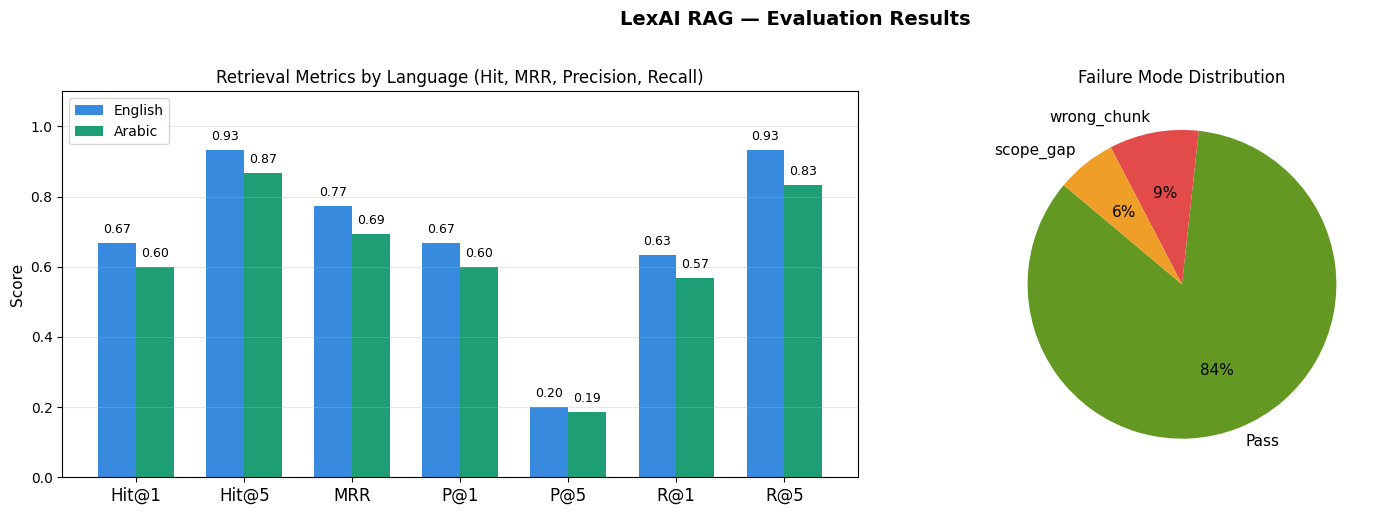

✅ Chart saved to eval_charts.png


In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def safe_mean(lst): return float(np.mean(lst)) if lst else 0.0

graded = [r for r in eval_results if r.expected_ids]
en_res = [r for r in graded if r.lang == "en"]
ar_res = [r for r in graded if r.lang == "ar"]

metrics = {
    "Hit@1" : [
        safe_mean([r.hit_at_1 for r in en_res]),
        safe_mean([r.hit_at_1 for r in ar_res]),
    ],
    "Hit@5" : [
        safe_mean([r.hit_at_5 for r in en_res]),
        safe_mean([r.hit_at_5 for r in ar_res]),
    ],
    "MRR"   : [
        safe_mean([r.mrr for r in en_res]),
        safe_mean([r.mrr for r in ar_res]),
    ],
    "P@1"   : [
        safe_mean([r.precision_at_1 for r in en_res]),
        safe_mean([r.precision_at_1 for r in ar_res]),
    ],
    "P@5"   : [
        safe_mean([r.precision_at_5 for r in en_res]),
        safe_mean([r.precision_at_5 for r in ar_res]),
    ],
    "R@1"   : [
        safe_mean([r.recall_at_1 for r in en_res]),
        safe_mean([r.recall_at_1 for r in ar_res]),
    ],
    "R@5"   : [
        safe_mean([r.recall_at_5 for r in en_res]),
        safe_mean([r.recall_at_5 for r in ar_res]),
    ],
}

x      = np.arange(len(metrics))
width  = 0.35
colors = ["#378ADD", "#1D9E75"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("LexAI RAG — Evaluation Results", fontsize=14, fontweight="bold", y=1.02)

# ── Bar chart: retrieval metrics ──────────────────────────────────────────────
ax = axes[0]
bars_en = ax.bar(x - width/2, [v[0] for v in metrics.values()], width, label="English", color=colors[0])
bars_ar = ax.bar(x + width/2, [v[1] for v in metrics.values()], width, label="Arabic",  color=colors[1])
ax.set_xticks(x)
ax.set_xticklabels(metrics.keys(), fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Retrieval Metrics by Language (Hit, MRR, Precision, Recall)", fontsize=12)
ax.legend()
ax.grid(axis="y", alpha=0.3)
for bar in [*bars_en, *bars_ar]:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.02,
            f"{h:.2f}", ha="center", va="bottom", fontsize=9)

# ── Pie chart: failure modes ──────────────────────────────────────────────────
ax2 = axes[1]
failure_counts = Counter(r.failure_mode for r in eval_results if r.failure_mode)
pass_count     = sum(1 for r in eval_results if r.failure_mode is None)
labels   = ["Pass"] + list(failure_counts.keys())
sizes    = [pass_count] + list(failure_counts.values())
palette  = ["#639922", "#E24B4A", "#EF9F27", "#7F77DD", "#D4537E"]
ax2.pie(sizes, labels=labels, autopct="%1.0f%%", colors=palette[:len(labels)],
        startangle=140, textprops={"fontsize": 11})
ax2.set_title("Failure Mode Distribution", fontsize=12)

plt.tight_layout()
plt.savefig("eval_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved to eval_charts.png")